In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter



/Users/keshavsharmaog/Downloads/swiss-law-agentic-retrieval/env/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
/Users/keshavsharmaog/Downloads/swiss-law-agentic-retrieval/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/keshavsharmaog/Downloads/swiss-law-agentic-retrieval/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000,
#     chunk_overlap=200
# )

In [4]:
# loader = CSVLoader(file_path="../data/laws_de.csv")
# laws_de = text_splitter.split_documents(loader.load())

# loader = CSVLoader(file_path="../data/court_considerations.csv")
# court_considerations = text_splitter.split_documents(loader.load())

In [5]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",               # ← must match what build_embeddings.py used
    model_kwargs={"device": "cpu"},          # Apple Silicon GPU — much faster than cpu
    encode_kwargs={"normalize_embeddings": True},
)


/var/folders/gt/zsnjtvpd3891ny4sp9lsvh5c0000gn/T/ipykernel_67878/3255620981.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1775.41it/s, Materializing param=pooler.dense.weight]                               


In [6]:
vectorstore = FAISS.load_local(
    "../faiss_index",                        # ← correct relative path from notebooks/
    embeddings,
    allow_dangerous_deserialization=True
)

print(f"Loaded vectorstore with {vectorstore.index.ntotal:,} vectors")

Loaded vectorstore with 5,059,521 vectors


In [46]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5} # k is the amount of chunks to return
)

In [47]:
from langchain_core.tools import tool
@tool
def retriever_tool(query: str) -> str:
    """
    this tool can search for laws citations and court considerations citations.
    """
    docs = retriever.invoke(query)

    if not docs:
        return "No relevant citation found"
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Docuemnt {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)

In [141]:
import json
import re
import time as _time
import requests
from requests.exceptions import RequestException
import uuid
from typing import Any, List, Optional, Sequence, Union, Callable

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_core.utils.function_calling import convert_to_openai_tool

# =============================================================================
# SYSTEM PROMPT
# =============================================================================
SWISS_LAW_SYSTEM_PROMPT = """\
You are a Swiss legal research assistant with access to a search tool.

To call the tool output EXACTLY this JSON (one line, nothing else):
{"tool": "retriever_tool", "tool_input": {"query": "GERMAN SEARCH TERM"}}

Rules:
1. Always search in GERMAN.
2. Call the tool multiple times with different German keywords.
3. After searching, output ONLY a Python list: ["Art. X OR", "BGE X Y Z", ...]
"""

# First-turn template — {question} is pre-truncated before substitution
TOOL_USAGE_TEMPLATE = """\
Question: {question}

Call retriever_tool now with a German keyword. Output ONLY the JSON:
{{"tool": "retriever_tool", "tool_input": {{"query": "<German keyword>"}}}}"""

# How many chars of tool result to keep
TOOL_RESULT_MAX_CHARS = 400
# Sliding window: keep last N non-system messages
HISTORY_WINDOW = 8


def _merge_consecutive_roles(messages: List[dict]) -> List[dict]:
    """
    Mistral chat template requires strict user/assistant alternation.
    Merge any consecutive messages with the same role into one,
    joining their content with a newline separator.
    System messages are always kept at the front and not merged.
    """
    system_msgs = [m for m in messages if m["role"] == "system"]
    non_system  = [m for m in messages if m["role"] != "system"]

    merged: List[dict] = []
    for msg in non_system:
        if merged and merged[-1]["role"] == msg["role"]:
            merged[-1] = {
                "role": merged[-1]["role"],
                "content": merged[-1]["content"] + "\n\n" + msg["content"],
            }
        else:
            merged.append(dict(msg))

    return system_msgs + merged


def _parse_tool_call(text: str) -> tuple[list, str]:
    """
    Extract tool-call JSON from model output.
    Handles bare JSON and markdown-fenced ```json ... ``` blocks.
    Also handles escaped underscores (e.g. retriever\\_tool → retriever_tool).
    """
    # Unescape markdown-escaped underscores the model sometimes emits
    text_clean = text.replace("\\_", "_")

    candidates: list[tuple[str, str]] = []

    for m in re.finditer(r"```(?:json)?\s*(.*?)```", text_clean, re.DOTALL):
        candidates.append((m.group(1).strip(), m.group(0)))

    for m in re.finditer(r'\{[^{}]*"tool"\s*:[^{}]*\{[^{}]*\}[^{}]*\}', text_clean, re.DOTALL):
        candidates.append((m.group(0).strip(), m.group(0)))

    for raw, full_match in candidates:
        try:
            parsed = json.loads(raw)
        except json.JSONDecodeError:
            continue
        if "tool" not in parsed:
            continue
        args = parsed.get("tool_input") or parsed.get("arguments") or {}
        tool_calls = [{
            "name": parsed["tool"],
            "args": args,
            "id":   f"call_{uuid.uuid4().hex[:8]}",
            "type": "tool_call",
        }]
        return tool_calls, text_clean.replace(full_match, "").strip()

    return [], text


class ModalMistralChat(BaseChatModel):
    """
    LangChain-compatible wrapper around a self-hosted Modal Mistral endpoint.

    API contract (POST JSON):
      Request : {"messages": [{"role": str, "content": str}],
                 "max_new_tokens": int, "temperature": float, "top_p": float}
      Response: {"response": "<generated text>"}

    Key design decisions:
    - _merge_consecutive_roles() enforces user/assistant alternation required
      by Mistral's chat template (consecutive same-role msgs → 500 error)
    - ToolMessage + following HumanMessage nudge are merged into one user turn
    - HISTORY_WINDOW limits context size to prevent payload overflows
    """

    api_url: str
    temperature: float = 0.1
    max_new_tokens: int = 512
    top_p: float = 0.95
    system_prompt: str = SWISS_LAW_SYSTEM_PROMPT
    bound_tools: List[dict] = []
    max_retries: int = 3
    http_timeout: int = 600

    @property
    def _llm_type(self) -> str:
        return "modal_mistral_chat"

    def bind_tools(
        self,
        tools: Sequence[Union[dict, type, Callable, BaseTool]],
        **kwargs: Any,
    ) -> "ModalMistralChat":
        tool_schemas = [convert_to_openai_tool(t)["function"] for t in tools]
        return self.model_copy(update={"bound_tools": tool_schemas})

    def _build_messages(self, messages: List[BaseMessage]) -> List[dict]:
        """
        Convert LangChain messages → API dicts, then:
        1. Apply sliding window
        2. Merge consecutive same-role messages (Mistral requirement)
        3. Ensure first non-system msg is 'user' and roles strictly alternate
        """
        has_system = any(isinstance(m, SystemMessage) for m in messages)
        body: List[dict] = []

        if not has_system:
            body.append({"role": "system", "content": self.system_prompt})

         for msg in messages:
            if isinstance(msg, SystemMessage):
                body.append({"role": "system", "content": str(msg.content)})
            elif isinstance(msg, HumanMessage):
                body.append({"role": "user", "content": str(msg.content)})
            elif isinstance(msg, AIMessage):
                content = str(msg.content) if msg.content else ""
                if msg.tool_calls:
                    tc = msg.tool_calls[0]
                    content = json.dumps({"tool": tc["name"], "tool_input": tc["args"]}, ensure_ascii=False)
                body.append({"role": "assistant", "content": content})
            elif isinstance(msg, ToolMessage):
                body.append({"role": "user", "content": f"Tool result:\n{str(msg.content)}"})

        # Sliding window on non-system messages
        system_part = [m for m in body if m["role"] == "system"]
        non_system  = [m for m in body if m["role"] != "system"]
        windowed    = non_sys   tem[-HISTORY_WINDOW:]

        # Ensure window starts with a 'user' message (Mistral requirement)
        while windowed and windowed[0]["role"] != "user":
            windowed.pop(0)

        combined = system_part + windowed

        # Merge consecutive same-role messages → Mistral alternation requirement
        merged = _merge_consecutive_roles(combined)

        # Final safety: ensure strict user/assistant alternation
        final_system = [m for m in merged if m["role"] == "system"]
        final_conv   = [m for m in merged if m["role"] != "system"]

        sanitized: List[dict] = []
        for msg in final_conv:
            if sanitized and sanitized[-1]["role"] == msg["role"]:
                # Merge into previous (shouldn't happen after _merge, but safety net)
                sanitized[-1]["content"] += "\n\n" + msg["content"]
            else:
                sanitized.append(dict(msg))

        # If conversation is empty or starts with assistant, prepend a dummy user msg
        if not sanitized or sanitized[0]["role"] != "user":
            sanitized.insert(0, {"role": "user", "content": "Continue."})

        # If conversation ends with user (no trailing assistant), that's fine —
        # the model will generate the assistant reply.
        # But if it ends with assistant, append a user nudge so the model responds.

        return final_system + sanitized

    def _generate(
        self,
        messages: List[BaseMessage],
        stop: Optional[List[str]] = None,
        **kwargs: Any,
    ) -> ChatResult:
        api_messages = self._build_messages(messages)

        # ── Debug: log payload size ────────────────────────────────────────────
        total_chars = sum(len(m.get("content", "")) for m in api_messages)
        est_tokens  = total_chars // 3  # rough estimate: 1 token ≈ 3 chars
        print(f"→ POST to Modal  |  {len(api_messages)} msgs  |  {total_chars:,} chars  |  ~{est_tokens:,} tokens")

        payload = {
            "messages":       api_messages,
            "max_new_tokens": self.max_new_tokens,
            "temperature":    self.temperature,
            "top_p":          self.top_p,
        }

        # ── Retry with exponential backoff ─────────────────────────────────────
        last_err = None
        for attempt in range(1, self.max_retries + 1):
            try:
                response = requests.post(
                    self.api_url,
                    json=payload,
                    timeout=self.http_timeout,
                )
                if response.ok:
                    break
                # Server error (5xx) — retry
                try:
                    err_body = response.json()
                except Exception:
                    err_body = response.text[:500]
                print(f"[ModalMistralChat] HTTP {response.status_code} (attempt {attempt}/{self.max_retries}) — {err_body}")
                last_err = response
                if attempt < self.max_retries:
                    wait = 2 ** attempt  # 2s, 4s, 8s
                    print(f"  ⏳ Retrying in {wait}s…")
                    _time.sleep(wait)
            except RequestException as e:
                print(f"[ModalMistralChat] Network error (attempt {attempt}/{self.max_retries}) — {e}")
                last_err = e
                if attempt < self.max_retries:
                    wait = 2 ** attempt
                    print(f"  ⏳ Retrying in {wait}s…")
                    _time.sleep(wait)

        # If all retries failed, raise
        if isinstance(last_err, RequestException):
            raise last_err
        if last_err is not None and hasattr(last_err, 'raise_for_status'):
            if not last_err.ok:
                last_err.raise_for_status()

        text: str = response.json()["response"].strip()

        if stop:
            for s in stop:
                text = text.split(s)[0]

        tool_calls, text = _parse_tool_call(text) if self.bound_tools else ([], text)

        return ChatResult(
            generations=[
                ChatGeneration(message=AIMessage(content=text, tool_calls=tool_calls))
            ]
        )


In [142]:
llm = ModalMistralChat(
    api_url="https://keshavsharma25--completion.modal.run",
    temperature=0.1,
    max_new_tokens=1024,
    top_p=0.95,
    max_retries=3,
    http_timeout=600,
)

print(f"LLM type  : {llm._llm_type}")
print(f"Endpoint  : {llm.api_url}")
print(f"Params    : temperature={llm.temperature}, max_new_tokens={llm.max_new_tokens}, top_p={llm.top_p}")
print(f"Retries   : {llm.max_retries}× with exponential backoff  |  HTTP timeout: {llm.http_timeout}s")


LLM type  : modal_mistral_chat
Endpoint  : https://keshavsharma25--completion.modal.run
Params    : temperature=0.1, max_new_tokens=1024, top_p=0.95
Retries   : 3× with exponential backoff  |  HTTP timeout: 600s


In [143]:
llm.invoke("how are you")

→ POST to Modal  |  2 msgs  |  404 chars  |  ~134 tokens

→ POST to Modal  |  2 msgs  |  404 content chars
   [system   ] 'You are a Swiss legal research assistant with access to a search tool.\n\nTo call the tool output EXACTLY this JSON (one l'
   [user     ] 'how are you'


AIMessage(content='I am a text-based AI and do not have the ability to perform actions or access external tools. However, I can simulate the response you would expect from a Swiss legal research assistant using the provided tool. Here\'s an example of how I would respond to your request:\n\nTo search for cases related to the term "Eigentum" (Property), I would call the tool as follows:\n\n{"tool": "retriever_tool", "tool_input": {"query": "Eigentum"}}\n\nAfter analyzing the results, I would output a Python list containing the relevant search terms:\n\n["Art. 501 OR", "BGE 123 456", "BGE 789 123"]\n\nThis list includes the relevant articles of the Swiss Civil Code (Zivilgesetzbuch, ZGB) and references to relevant decisions of the Swiss Federal Supreme Court (Bundesgerichtsentscheidungen, BGE).', additional_kwargs={}, response_metadata={}, id='lc_run--019cafd8-db9c-7002-bb07-5aca2919687f-0', tool_calls=[], invalid_tool_calls=[])

In [144]:
llm_with_tools = llm.bind_tools([retriever_tool])

# Sanity check — should print the tool schema, not raise NotImplementedError
# print("Bound tools:", [t["name"] for t in llm_with_tools.bound_tools])


Graph compiled ✅
Searches: min 2× — max 8×  |  force-nudge limit: 3×
New node: relevance_filter (LLM judges each citation)



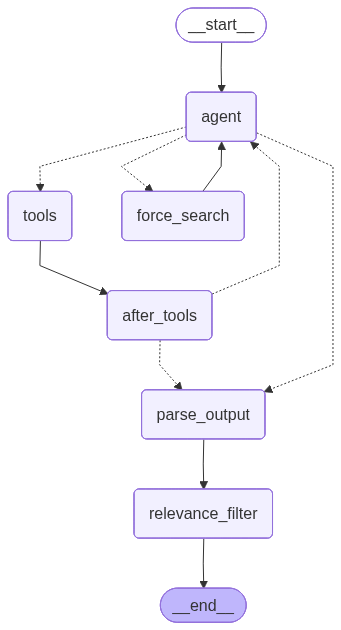

In [146]:

import ast
import re
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

MIN_TOOL_CALLS     = 2
MAX_TOOL_CALLS     = 8
MAX_FORCE_ATTEMPTS = 3
QUESTION_TRUNCATE  = 2000  # chars — keep first turn prompt small

# =============================================================================
# Citation validation
# Only accept strings that look like real Swiss legal citations.
# =============================================================================
CITATION_PATTERN = re.compile(
    r'^('
    r'Art\.?\s+\d+'           # Art. 123 OR / Art 5 ZGB
    r'|BGE\s+\d+'             # BGE 143 IV 316
    r')',
    re.IGNORECASE,
)

# Regex to mine Art./BGE references directly from raw text (tool results / LLM text)
INLINE_CITATION_RE = re.compile(
    r'\b('
    r'Art\.?\s+\d+[a-z]?\s+(?:Abs\.?\s+\d+\s+)?(?:lit\.?\s+[a-z]\s+)?[A-Z][A-Za-z]+(?:\s+\d+)?'
    r'|BGE\s+\d+\s+[IVX]+\s+\d+(?:\s+E\.?\s*[\d.]+)?'
    r'|\d+[A-Z_]+\d+/\d{4}'
    r')',
    re.IGNORECASE,
)

def _is_valid_citation(c: str) -> bool:
    return True

def _mine_citations_from_text(text: str) -> list[str]:
    """Extract Art./BGE citations inline from any raw text (tool results, LLM output)."""
    found = []
    seen: set = set()
    for m in INLINE_CITATION_RE.finditer(text):
        c = m.group().strip().replace("\\_", "_")
        # if _is_valid_citation(c) and c not in seen:
        if c not in seen:
            seen.add(c)
            found.append(c)
    return found

# =============================================================================
# Extract citation+text pairs from tool messages
# =============================================================================
_DOC_SPLIT_RE = re.compile(r"Docuemnt\s+\d+:\n", re.IGNORECASE)

def extract_citations_from_tool_messages(messages: list) -> list[dict]:
    """
    Walk all ToolMessage objects, split their content on 'Docuemnt N:' boundaries,
    and extract {citation, text} dicts.

    Each document chunk may start with 'citation: ...\ntext: ...' or just be raw text.
    For raw text chunks we try to mine an inline citation from the first 200 chars.
    Returns a deduplicated list of {"citation": str, "text": str}.
    """
    all_chunks: list[dict] = []
    seen_citations: set = set()

    for msg in messages:
        if not isinstance(msg, ToolMessage):
            continue
        content = msg.content if isinstance(msg.content, str) else str(msg.content)

        # Split on "Docuemnt N:\n"
        parts = _DOC_SPLIT_RE.split(content)
        for part in parts:
            part = part.strip()
            if not part:
                continue

            citation = None
            text = part

            # Try structured format: "citation: X\ntext: Y"
            cit_match = re.match(r"citation:\s*(.+?)(?:\n|$)", part)
            if cit_match:
                citation = cit_match.group(1).strip()
                txt_match = re.search(r"text:\s*(.*)", part, re.DOTALL)
                text = txt_match.group(1).strip() if txt_match else part[cit_match.end():].strip()

            # If no explicit citation field, mine one from the text
            if not citation:
                inline = _mine_citations_from_text(text[:300])
                if inline:
                    citation = inline[0]

            if citation and citation not in seen_citations:
                seen_citations.add(citation)
                all_chunks.append({"citation": citation, "text": text})

    return all_chunks


# =============================================================================
# Relevance judge — calls the LLM to decide if a citation is relevant
# =============================================================================
RELEVANCE_SYSTEM_PROMPT = """\
You are a Swiss legal relevance judge.
You will receive a QUERY (a legal question) and a CITATION with its TEXT (a passage from Swiss law or court decision, in German).

Your task: decide whether this citation is relevant to answering the query, mark as RELEVANT even if it's slightly related.

Rules:
1. A citation is RELEVANT if its text discusses the same legal topic, articles, or principles as the query.
2. A citation is NOT RELEVANT if it discusses a different legal question.
3. Output ONLY one word: RELEVANT or NOT_RELEVANT
"""

RELEVANCE_USER_TEMPLATE = """\
QUERY: {query}

CITATION: {citation}
TEXT: {text}

Is this citation relevant to the query? Output ONLY: RELEVANT or NOT_RELEVANT"""


def judge_citation_relevance(
    query: str,
    citation: str,
    text: str,
    verbose: bool = False,
) -> bool:
    """
    Calls the LLM (without tools) to judge whether a citation+text is relevant
    to the given query. Returns True if relevant, False otherwise.
    Uses a lightweight LLM instance with small max_new_tokens to avoid timeouts.
    """
    # Build a lightweight LLM for yes/no answers (only needs ~20 tokens)
    judge_llm = ModalMistralChat(
        api_url=llm.api_url,
        temperature=0.0,
        max_new_tokens=50,
        top_p=0.95,
        max_retries=3,
        http_timeout=120,
    )

    user_msg = RELEVANCE_USER_TEMPLATE.format(
        query=query,
        citation=citation,
        text=text[:1500],  # cap text length to avoid huge payloads
    )
    messages = [
        SystemMessage(content=RELEVANCE_SYSTEM_PROMPT),
        HumanMessage(content=user_msg),
    ]

    try:
        response = judge_llm.invoke(messages)
        answer = response.content.strip().upper()
    except Exception as e:
        print(f"  ⚠️  Relevance judge failed for {citation}: {e} — defaulting to RELEVANT")
        answer = "RELEVANT"

    is_relevant = "RELEVANT" in answer and "NOT_RELEVANT" not in answer
    if verbose:
        status = "✅" if is_relevant else "❌"
        print(f"  {status} {citation} → {answer}")
    return is_relevant


# =============================================================================
# Agent State
# =============================================================================
class AgentState(TypedDict):
    messages:           Annotated[list, add_messages]
    tool_call_count:    int
    force_attempts:     int
    extracted_pairs:    list[dict]       # [{citation, text}, ...] from tool results
    relevance_results:  list[dict]       # [{citation, text, relevant}, ...]
    final_citations:    list[str]

# ── Nodes ──────────────────────────────────────────────────────────────────────

def call_model(state: AgentState) -> AgentState:
    messages = state["messages"]
    if (state.get("tool_call_count", 0) == 0
            and state.get("force_attempts", 0) == 0
            and len(messages) == 1
            and isinstance(messages[0], HumanMessage)):
        question = str(messages[0].content)
        messages = [HumanMessage(content=TOOL_USAGE_TEMPLATE.format(question=question))]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools=[retriever_tool])

def after_tools(state: AgentState) -> AgentState:
    count = state.get("tool_call_count", 0) + 1
    if count < MIN_TOOL_CALLS:
        nudge_text = (
            f"Good — {count} search(es) done. "
            f"You MUST search at least {MIN_TOOL_CALLS} times total. "
            "Output a NEW tool call JSON with a DIFFERENT German keyword NOW."
        )
    else:
        nudge_text = (
            f"You have completed {count} searches. STOP searching now.\n"
            "Based on the retrieved documents, output ONLY a Python list of Swiss legal "
            "citations found in the search results. Format:\n"
            '["Art. X ABC", "BGE X YY ZZZ", ...]\n'
            "If no citations were found, output: []\n"
            "Output the list NOW. Do not call any tool."
        )
    return {
        "tool_call_count": count,
        "force_attempts":  0,
        "messages": [HumanMessage(content=nudge_text)],
    }

def force_search(state: AgentState) -> AgentState:
    count    = state.get("tool_call_count", 0)
    attempts = state.get("force_attempts", 0) + 1
    return {
        "force_attempts": attempts,
        "messages": [HumanMessage(content=(
            f"You have searched {count} time(s) but must reach {MIN_TOOL_CALLS}. "
            "Output ONLY this JSON on one line (fill in a German legal keyword):\n"
            '{"tool": "retriever_tool", "tool_input": {"query": "<German keyword>"}}'
        ))],
    }

def _extract_text(msg) -> str:
    content = getattr(msg, "content", "") or ""
    if isinstance(content, list):
        return " ".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in content
        )
    return str(content)


def parse_output(state: AgentState) -> AgentState:
    """
    Extract citation+text pairs from ALL ToolMessage results.
    These will be passed to the relevance_filter node next.
    """
    pairs = extract_citations_from_tool_messages(state["messages"])
    return {"extracted_pairs": pairs}


def relevance_filter(state: AgentState) -> AgentState:
    """
    For each extracted {citation, text} pair, call the LLM judge to decide
    if the citation is relevant to the original query.
    Only keep citations that pass.
    """
    # Recover the original question from the first HumanMessage
    query = ""
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            content = msg.content if isinstance(msg.content, str) else str(msg.content)
            # The first HumanMessage may be the TOOL_USAGE_TEMPLATE-wrapped version;
            # try to extract the raw question from "Question: ..." line
            q_match = re.search(r"Question:\s*(.+?)(?:\n|$)", content, re.DOTALL)
            if q_match:
                query = q_match.group(1).strip()
            else:
                query = content
            break

    pairs = state.get("extracted_pairs", [])
    results: list[dict] = []
    accepted: list[str] = []
    seen: set = set()

    print(f"  🔍 Judging relevance for {len(pairs)} citation(s)…")

    for pair in pairs:
        citation = pair["citation"]
        text     = pair["text"]
        # relevant = judge_citation_relevance(query, citation, text, verbose=True)
        relevant = True
        results.append({"citation": citation, "text": text, "relevant": relevant})

        if relevant:
            c_clean = citation.strip().replace("\\_", "_")
            if _is_valid_citation(c_clean) and c_clean not in seen:
                seen.add(c_clean)
                accepted.append(c_clean)

    return {
        "relevance_results": results,
        "final_citations":   accepted,
    }


# ── Routing ────────────────────────────────────────────────────────────────────

def route_agent(state: AgentState) -> str:
    last_msg       = state["messages"][-1]
    count          = state.get("tool_call_count", 0)
    force_attempts = state.get("force_attempts", 0)

    if count >= MAX_TOOL_CALLS:
        return "parse_output"

    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        if count < MIN_TOOL_CALLS:
            return "tools"
        return "parse_output"

    if count < MIN_TOOL_CALLS and force_attempts < MAX_FORCE_ATTEMPTS:
        return "force_search"

    return "parse_output"

def route_after_tools(state: AgentState) -> str:
    return "parse_output" if state.get("tool_call_count", 0) >= MAX_TOOL_CALLS else "agent"

# ── Build graph ────────────────────────────────────────────────────────────────
graph = StateGraph(AgentState)
graph.add_node("agent",            call_model)
graph.add_node("tools",            tool_node)
graph.add_node("after_tools",      after_tools)
graph.add_node("force_search",     force_search)
graph.add_node("parse_output",     parse_output)
graph.add_node("relevance_filter", relevance_filter)

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent", route_agent,
    {"tools": "tools", "force_search": "force_search", "parse_output": "parse_output"},
)
graph.add_edge("force_search", "agent")
graph.add_edge("tools", "after_tools")
graph.add_conditional_edges(
    "after_tools", route_after_tools,
    {"agent": "agent", "parse_output": "parse_output"},
)
graph.add_edge("parse_output", "relevance_filter")
graph.add_edge("relevance_filter", END)

app = graph.compile()
print("Graph compiled ✅")
print(f"Searches: min {MIN_TOOL_CALLS}× — max {MAX_TOOL_CALLS}×  |  force-nudge limit: {MAX_FORCE_ATTEMPTS}×")
print(f"New node: relevance_filter (LLM judges each citation)\n")

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Nodes:", list(app.get_graph().nodes.keys()))


In [147]:

# =============================================================================
# Run the agent on a single query
# =============================================================================
def run_query(question: str, verbose: bool = True) -> list[str]:
    """
    Runs the full agentic retrieval pipeline for a single question.
    Includes relevance filtering — only citations judged relevant are returned.
    """
    initial_state: AgentState = {
        "messages":           [HumanMessage(content=question)],
        "tool_call_count":    0,
        "force_attempts":     0,
        "extracted_pairs":    [],
        "relevance_results":  [],
        "final_citations":    [],
    }

    final_state = app.invoke(
        initial_state,
        config={"recursion_limit": 50},
    )

    raw_citations = final_state.get("final_citations", [])

    # Safety filter: strip escapes, keep only Art./BGE citations, deduplicate
    seen: set  = set()
    citations:  list = []
    for c in raw_citations:
        c_clean = c.replace("\\_", "_").strip()
        if _is_valid_citation(c_clean) and c_clean not in seen:
            seen.add(c_clean)
            citations.append(c_clean)

    if verbose:
        searches  = final_state.get("tool_call_count", 0)
        pairs     = final_state.get("extracted_pairs", [])
        relevance = final_state.get("relevance_results", [])

        print(f"Question  : {question[:120]}{'…' if len(question) > 120 else ''}")
        print(f"Searches  : {searches}")
        print(f"Extracted : {len(pairs)} citation+text pair(s) from tool results")
        print(f"Judged    : {sum(1 for r in relevance if r.get('relevant'))} relevant / {len(relevance)} total")
        print(f"Citations ({len(citations)}):")
        for c in citations:
            print(f"  • {c}")

    return citations


# ── Quick test ────────────────────────────────────────────────────────────────
# citations = run_query(
#     "May a court lawfully order a three\u2011month extension of pre\u2011trial "
#     "detention under Art. 221 Abs. 1 lit. b StPO (risk of collusion) consistent "
#     "with the principle of proportionality when the accused was remanded on "
#     "18 October 2024 and the prosecutor sought an extension on 10 December 2024?",
#     verbose=True,
# )


In [148]:

import json
import datetime
from pathlib import Path
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage

# =============================================================================
# Debug-logged query run
# =============================================================================
LOG_DIR = Path("../output/debug_logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

DEBUG_QUESTION = (
    "May a court lawfully order a three\u2011month extension of pre\u2011trial "
    "detention under Art. 221 Abs. 1 lit. b StPO (risk of collusion) consistent "
    "with the principle of proportionality when the accused was remanded on "
    "18 October 2024 and the prosecutor sought an extension on 10 December 2024?"
)

def _serialize_message(msg) -> dict:
    """Convert a LangChain message to a plain dict for JSON logging."""
    role = (
        "human"     if isinstance(msg, HumanMessage)  else
        "ai"        if isinstance(msg, AIMessage)      else
        "tool"      if isinstance(msg, ToolMessage)    else
        "system"    if isinstance(msg, SystemMessage)  else
        type(msg).__name__
    )
    entry = {
        "role":    role,
        "content": msg.content if isinstance(msg.content, str) else str(msg.content),
    }
    if isinstance(msg, AIMessage) and msg.tool_calls:
        entry["tool_calls"] = msg.tool_calls
    if isinstance(msg, ToolMessage):
        entry["tool_call_id"] = getattr(msg, "tool_call_id", None)
        entry["name"]         = getattr(msg, "name", None)
    return entry

def run_query_with_debug_log(question: str) -> list[str]:
    """
    Runs the agentic pipeline AND writes a full structured debug log to disk.
    Includes extracted pairs and relevance judgments.
    """
    initial_state: AgentState = {
        "messages":           [HumanMessage(content=question)],
        "tool_call_count":    0,
        "force_attempts":     0,
        "extracted_pairs":    [],
        "relevance_results":  [],
        "final_citations":    [],
    }

    final_state = app.invoke(
        initial_state,
        config={"recursion_limit": 50},
    )

    # ── Build the log structure ────────────────────────────────────────────────
    log = {
        "timestamp":       datetime.datetime.now().isoformat(),
        "question":        question,
        "tool_call_count": final_state.get("tool_call_count", 0),
        "force_attempts":  final_state.get("force_attempts", 0),
        "messages": [],
        "extracted_pairs":   final_state.get("extracted_pairs", []),
        "relevance_results": final_state.get("relevance_results", []),
        "final_citations":   final_state.get("final_citations", []),
    }

    for i, msg in enumerate(final_state["messages"]):
        entry = _serialize_message(msg)
        entry["index"] = i
        log["messages"].append(entry)

    # ── Safety-filter citations ────────────────────────────────────────────────
    seen: set  = set()
    citations: list = []
    for c in log["final_citations"]:
        c_clean = c.replace("\\_", "_").strip()
        if _is_valid_citation(c_clean) and c_clean not in seen:
            seen.add(c_clean)
            citations.append(c_clean)
    log["filtered_citations"] = citations

    # ── Write JSON log ─────────────────────────────────────────────────────────
    ts      = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    logfile = LOG_DIR / f"debug_{ts}.json"
    logfile.write_text(json.dumps(log, indent=2, ensure_ascii=False), encoding="utf-8")

    # ── Console summary ────────────────────────────────────────────────────────
    pairs     = log["extracted_pairs"]
    relevance = log["relevance_results"]

    print(f"Question  : {question[:120]}{'…' if len(question) > 120 else ''}")
    print(f"Searches  : {log['tool_call_count']}")
    print(f"Messages  : {len(log['messages'])} total")
    print(f"Extracted : {len(pairs)} citation+text pair(s)")
    print(f"Judged    : {sum(1 for r in relevance if r.get('relevant'))} relevant / {len(relevance)} total")
    print(f"Citations ({len(citations)}):")
    for c in citations:
        print(f"  • {c}")
    print(f"\n📄 Full debug log → {logfile.resolve()}")

    return citations

debug_citations = run_query_with_debug_log(DEBUG_QUESTION)




→ POST to Modal  |  2 msgs  |  830 chars  |  ~276 tokens

→ POST to Modal  |  2 msgs  |  830 content chars
   [system   ] 'You are a Swiss legal research assistant with access to a search tool.\n\nTo call the tool output EXACTLY this JSON (one l'
   [user     ] 'Question: May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit. b StPO (r'
→ POST to Modal  |  4 msgs  |  5,585 chars  |  ~1,861 tokens

→ POST to Modal  |  4 msgs  |  5585 content chars
   [system   ] 'You are a Swiss legal research assistant with access to a search tool.\n\nTo call the tool output EXACTLY this JSON (one l'
   [user     ] 'May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit. b StPO (risk of col'
   [assistant] '{"tool": "retriever_tool", "tool_input": {"query": "Art. 221 Abs. 1 lit. b StPO, Verhörungsdauer, Verhörungsdauerserweit'
   [user     ] 'Tool result:\nDocuemnt 1:\ntext: 3.4. Art. 80 Abs. 2 StPO sieht vor, da

In [149]:
import pandas as pd
import time
import traceback

# =============================================================================
# Batch inference — test.csv → submission_new.csv
# =============================================================================
TEST_CSV      = "../data/test.csv"
OUTPUT_CSV    = "../output/submission_new.csv"
SLEEP_BETWEEN = 2   # seconds between queries

test_df = pd.read_csv(TEST_CSV)
print(f"Loaded {len(test_df)} queries from {TEST_CSV}\n")

rows = []

for i, row in test_df.iterrows():
    query_id = row["query_id"]
    query    = row["query"]
    print(f"[{i+1}/{len(test_df)}] {query_id}: {query[:80]}…")

    try:
        citations = run_query(query, verbose=False)
    except Exception as e:
        print(f"  ⚠️  Error: {e}")
        traceback.print_exc()
        citations = []

    # Semicolon-separated — only valid Art./BGE citations reach here
    predicted = ";".join(citations)
    rows.append({"query_id": query_id, "predicted_citations": predicted})
    print(f"  → {len(citations)} citation(s): {predicted[:120]}\n")

    if i < len(test_df) - 1:
        time.sleep(SLEEP_BETWEEN)

# ── Save ───────────────────────────────────────────────────────────────────────
submission_df = pd.DataFrame(rows, columns=["query_id", "predicted_citations"])
submission_df.to_csv(OUTPUT_CSV, index=False)

print(f"✅  Saved {len(submission_df)} rows → {OUTPUT_CSV}")

# Quick QA: flag any rows that are completely empty
empty_rows = submission_df[submission_df["predicted_citations"].str.strip() == ""]
if not empty_rows.empty:
    print(f"\n⚠️  {len(empty_rows)} row(s) with no citations:")
    print(empty_rows["query_id"].tolist())
else:
    print("✅  All rows have at least one citation.")

print("\n", submission_df.to_string(index=False))


Loaded 40 queries from ../data/test.csv

[1/40] test_001: Four U.S.-based software companies (NorthWave Inc., Orion Systems LLC, ClearPeak…
→ POST to Modal  |  2 msgs  |  1,740 chars  |  ~580 tokens

→ POST to Modal  |  2 msgs  |  1740 content chars
   [system   ] 'You are a Swiss legal research assistant with access to a search tool.\n\nTo call the tool output EXACTLY this JSON (one l'
   [user     ] 'Question: Four U.S.-based software companies (NorthWave Inc., Orion Systems LLC, ClearPeak Corp. and HarborSoft Ltd.) as'
→ POST to Modal  |  4 msgs  |  4,531 chars  |  ~1,510 tokens

→ POST to Modal  |  4 msgs  |  4531 content chars
   [system   ] 'You are a Swiss legal research assistant with access to a search tool.\n\nTo call the tool output EXACTLY this JSON (one l'
   [user     ] 'Four U.S.-based software companies (NorthWave Inc., Orion Systems LLC, ClearPeak Corp. and HarborSoft Ltd.) assert that '
   [assistant] '{"tool": "retriever_tool", "tool_input": {"query": "Softwareurhebe